# データの特徴

In [1]:
!pip install optuna optuna-integration

# import lightgbm as lgb
import optuna.integration.lightgbm as lgb
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd

from sklearn import metrics
import matplotlib.pyplot as plt

import optuna

import os

/Users/shigeyuki-t/anaconda3/lib/python3.7/site-packages/dask/config.py:168: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  data = yaml.load(f.read()) or {}
/Users/shigeyuki-t/anaconda3/lib/python3.7/site-packages/distributed/config.py:20: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  defaults = yaml.load(f)


In [2]:
file_path = '/Users/shigeyuki-t/Desktop/FirstExperiment/分析/05.csv'
dataset = pd.read_csv(file_path)
dataset.head(3)

,Unnamed: 0,sensor_id,data_time,QuestionNum,choice_left,choice_right,event,isAnswerCorrect,response_time,response_time_ave,...,scroll_count,scroll_length,scroll_speed,scroll_time,tap_count,tap_interval,tap_position_x,tap_position_y,taskNum,view_position
0,0,suke.kazuma@gmail.com,2024-05-07 03:33:51,0,0,0,scroll,True,0.0,0.0,...,2,0.0,0.0,0.5,0,0.0,0.0,0.0,1,513.0
1,1,suke.kazuma@gmail.com,2024-05-07 03:33:50,0,0,0,scroll,True,0.0,0.0,...,1,935.0,9350.0,0.1,0,0.0,0.0,0.0,1,513.0
2,2,suke.kazuma@gmail.com,2024-05-07 03:33:55,0,1,0,response,True,0.0,0.0,...,2,0.0,0.0,0.5,1,0.0,0.0,0.0,1,513.0


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17872 entries, 0 to 17871
Data columns (total 22 columns):
Unnamed: 0           17872 non-null int64
sensor_id            17872 non-null object
data_time            17872 non-null object
QuestionNum          17872 non-null int64
choice_left          17872 non-null int64
choice_right         17872 non-null int64
event                17872 non-null object
isAnswerCorrect      17872 non-null bool
response_time        17872 non-null float64
response_time_ave    17872 non-null float64
screen_height        17872 non-null int64
screen_width         17872 non-null int64
scroll_count         17872 non-null int64
scroll_length        17872 non-null float64
scroll_speed         17872 non-null float64
scroll_time          17872 non-null float64
tap_count            17872 non-null int64
tap_interval         17872 non-null float64
tap_position_x       17872 non-null float64
tap_position_y       17872 non-null float64
taskNum              17872 non-nu

In [4]:
dataset.describe()

,Unnamed: 0,QuestionNum,choice_left,choice_right,response_time,response_time_ave,screen_height,screen_width,scroll_count,scroll_length,scroll_speed,scroll_time,tap_count,tap_interval,tap_position_x,tap_position_y,taskNum,view_position
count,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000,17872.000000
mean,8935.500000,77.161929,33.562892,31.261470,6.052865,11.362357,835.017122,392.941137,145.515947,305.285813,221.803827,4.667329,66.378973,5.644231,135.621505,191.429124,65.502238,29910.213153
std,5159.346341,44.273359,23.761142,21.657783,20.016043,8.647612,101.921501,18.623963,105.075389,1461.489288,2732.775480,10.639696,44.879529,18.626745,153.908233,213.912419,44.065405,19852.965286
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,600.000000,320.000000,1.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,4467.750000,40.000000,13.000000,12.000000,0.400000,7.367380,812.000000,375.000000,60.000000,23.666667,16.289386,0.900000,27.000000,0.400000,0.000000,0.000000,27.000000,12606.916667
50%,8935.500000,78.000000,30.000000,28.000000,2.200000,10.573256,844.000000,390.000000,127.000000,241.500000,58.333333,2.300000,61.000000,2.100000,36.333328,27.000000,60.000000,28231.250000
75%,13403.250000,117.000000,52.000000,49.000000,6.400000,12.513131,852.000000,414.000000,211.000000,388.000000,141.190476,5.500000,103.000000,6.200000,308.000000,417.500000,102.000000,46588.000000
max,17871.000000,151.000000,114.000000,89.000000,886.400000,114.666667,1194.000000,430.000000,484.000000,63917.666667,242237.500000,873.500000,159.000000,886.700000,531.500000,657.333328,151.000000,89287.500000


In [5]:
# フォルダ・ファイルの作成
dataset = dataset[(dataset['sensor_id'] != 'koizumi.riku.kv8@naist.jp') & (dataset['sensor_id'] != 'fukuryu115@gmail.com')]
# print(dataset['sensor_id'].value_counts())

unique_sensor_ids = dataset['sensor_id'].unique()
base_path = '/Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/'

for sensor_id in unique_sensor_ids:
    # フォルダ作成
    folder_name = f'{sensor_id}'
    folder_path = os.path.join(base_path, folder_name)
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f'created:b {folder_path}')
    else:
        print(f'already exists: {folder_path}')
    
    csv_name =  f'{sensor_id}' + '.csv'
    csv_path = '/Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/' + f'{sensor_id}' + '/' 
    mail_dataset = dataset[dataset['sensor_id'] == f'{sensor_id}']
    csv_create_location = os.path.join(csv_path, csv_name)
    mail_dataset.to_csv(csv_create_location, index = True)
    
    if not os.path.exists(csv_create_location):
        os.makedirs(csv_create_location)
        print(f'created:b {csv_create_location}')
    else:
        print(f'already exists: {csv_create_location}')

already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/suke.kazuma@gmail.com
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/suke.kazuma@gmail.com/suke.kazuma@gmail.com.csv
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/ishiyama.rin.ip5@naist.ac.jp
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/ishiyama.rin.ip5@naist.ac.jp/ishiyama.rin.ip5@naist.ac.jp.csv
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/maccus92_1@hotmail.my
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/maccus92_1@hotmail.my/maccus92_1@hotmail.my.csv
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/murata.takuma.mu9@naist.ac.jp
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/murata.takuma.mu9@naist.ac.jp/murata.takuma.mu9@naist.ac.jp.csv
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人/asatomo19991219@gmail.com
already exists: /Users/shigeyuki-t/Desktop/FirstExperiment/分析/個人

# データ成形

In [6]:
# for sensor_id in unique_sensor_ids:
#     # フォルダ作成
#     folder_name = f'{sensor_id}'
#     folder_path = os.path.join(base_path, folder_name)



# データの読み込み
data_clean = pd.read_csv('/Users/shigeyuki-t/Desktop/FirstExperiment/分析/datacheck.csv')

data_clean = data_clean[data_clean['taskNum'] < 151]

# True = 1, False = 0, レスポンス以外のときの値が-1
data_clean.loc[data_clean['event'] != 'response', 'isAnswerCorrect'] = np.nan
data_clean['isAnswerCorrect'].fillna(-1, inplace=True)

# data_timeをdatetimeに変換してソート
data_clean['data_time'] = pd.to_datetime(data_clean['data_time'])
data_clean = data_clean.sort_values(by='data_time')

# data_time の差分を秒単位で計算し、response_time に代入
data_clean.loc[data_clean['taskNum'] == 1, 'response_time'] = data_clean['data_time'].diff().dt.total_seconds().shift(-1)

# カテゴリ変数をダミー変数に変換
data_clean = pd.get_dummies(data_clean, columns=['event'])

# タップポジションを画面比に応じた値に変更
data_clean['ratio_tap_position_x'] = data_clean['tap_position_x'] / data_clean['screen_width']
data_clean['ratio_tap_position_y'] = data_clean['tap_position_y'] / data_clean['screen_height']

# スクロールの処理
data_clean['scroll_group'] = 0
group_number = 1
# 前の行の値を保存する変数
previous_value = data_clean.iloc[0]['scroll_time']
data_clean.at[0, 'scroll_group'] = group_number
# グループ分けのループ
for index in range(1, len(data_clean)):
    current_value = data_clean.iloc[index]['scroll_time']
    if current_value >= previous_value:
        data_clean.at[index, 'scroll_group'] = group_number
    else:
        group_number += 1
        data_clean.at[index, 'scroll_group'] = group_number
    previous_value = current_value

# scroll_timeが複数のtaskNumに跨って継続しているときの処理
max_task_num = data_clean['taskNum'].max()
for task_num in range(max_task_num):
    current_task_group = data_clean[data_clean['taskNum']==task_num]
    next_task_group = data_clean[data_clean['taskNum']==task_num+1]
    # np.intersect1dは複数配列の共通項を取り出す
    common_groups = np.intersect1d(current_task_group['scroll_group'].unique(),next_task_group['scroll_group'].unique())
    
    for group in common_groups:
        last_scroll_time_current = current_task_group[current_task_group['scroll_group'] == group]['scroll_time'].values[-1]
        data_clean.loc[(data_clean['taskNum'] == task_num + 1)&(data_clean['scroll_group'] == group),'scroll_time'] -= last_scroll_time_current

data_clean.head(20)

,Unnamed: 0,Unnamed: 0.1,sensor_id,data_time,QuestionNum,choice_left,choice_right,isAnswerCorrect,response_time,response_time_ave,...,tap_interval,tap_position_x,tap_position_y,taskNum,view_position,event_response,event_scroll,ratio_tap_position_x,ratio_tap_position_y,scroll_group
1,1,1,suke.kazuma@gmail.com,2024-05-07 03:33:50,0,0,0,-1.0,1.0,0.000000,...,0.0,0.0,0.0,1,513.000000,0,1,0.0,0.0,1
0,0,0,suke.kazuma@gmail.com,2024-05-07 03:33:51,0,0,0,-1.0,4.0,0.000000,...,0.0,0.0,0.0,1,513.000000,0,1,0.0,0.0,1
2,2,2,suke.kazuma@gmail.com,2024-05-07 03:33:55,0,1,0,1.0,0.0,0.000000,...,0.0,0.0,0.0,1,513.000000,1,0,0.0,0.0,1
3,3,3,suke.kazuma@gmail.com,2024-05-07 03:33:55,120,1,0,-1.0,0.0,0.000000,...,0.1,0.0,0.0,2,513.000000,0,1,0.0,0.0,1
4,4,4,suke.kazuma@gmail.com,2024-05-07 03:33:56,120,1,0,-1.0,0.4,0.000000,...,0.4,0.0,0.0,2,513.000000,0,1,0.0,0.0,2
5,5,5,suke.kazuma@gmail.com,2024-05-07 03:33:57,120,1,0,-1.0,1.6,0.000000,...,1.7,0.0,0.0,2,353.333333,0,1,0.0,0.0,2
6,6,6,suke.kazuma@gmail.com,2024-05-07 03:33:58,120,1,0,-1.0,2.4,0.000000,...,2.5,0.0,0.0,2,371.666667,0,1,0.0,0.0,3
7,7,7,suke.kazuma@gmail.com,2024-05-07 03:33:59,120,1,0,-1.0,4.1,0.000000,...,4.1,0.0,0.0,2,371.666667,0,1,0.0,0.0,3
8,8,8,suke.kazuma@gmail.com,2024-05-07 03:34:03,120,2,0,1.0,7.7,3.850000,...,7.7,0.0,0.0,2,371.666667,1,0,0.0,0.0,3
9,9,9,suke.kazuma@gmail.com,2024-05-07 03:34:03,51,2,0,-1.0,0.4,3.850000,...,0.4,0.0,0.0,3,245.000000,0,1,0.0,0.0,3


In [7]:
# taskNumが同じ行を１行にまとめる
# 集計方法を指定
aggregation_functions = {
    "choice_left": "max", 
    "choice_right": "max",
    "isAnswerCorrect": "max",
    "response_time": "max",
#     "response_time_ave": "mean",
    "screen_height": "max",
    "screen_width": "max",
    "scroll_count": "max",
    
    "scroll_length": "sum",
#     "scroll_speed": "mean",
    "scroll_time": "sum",
#     "sorted_scroll_time":"sum",
    
    "tap_count": "max",
#     "tap_interval": "mean",
    "tap_position_x": "max",
    "tap_position_y": "max",
    "ratio_tap_position_x": "max",
    "ratio_tap_position_y": "max",
    "view_position": "last",
    "event_response": "sum",
    "event_scroll": "sum" 
}

# グループ化して集計
df = data_clean .groupby("taskNum").agg(aggregation_functions).reset_index()

# 蓄積値を増加値に変更
df['s_choice_left'] = df['choice_left'].diff().fillna(df['choice_left'])
df['s_choice_right'] = df['choice_right'].diff().fillna(df['choice_right'])
df['s_tap_count'] = df['tap_count'].diff().fillna(df['tap_count'])
df['s_view_position'] = df['view_position'].diff().fillna(df['view_position'])

df = df.drop(columns=['choice_left','choice_right','tap_count','scroll_count','event_response','view_position','s_choice_right'	])

df['s_scroll_speed'] = df['scroll_length']/df['scroll_time']

df = df.replace([np.inf, -np.inf], np.nan)
df.fillna(0, inplace=True)  # NaNを0で埋める

csv_create_location = '/Users/shigeyuki-t/Desktop/FirstExperiment/分析/data０６２４.csv'
df.to_csv(csv_create_location, index = True)

df.head(151)

,taskNum,isAnswerCorrect,response_time,screen_height,screen_width,scroll_length,scroll_time,tap_position_x,tap_position_y,ratio_tap_position_x,ratio_tap_position_y,event_scroll,s_choice_left,s_tap_count,s_view_position,s_scroll_speed
0,1,1.0,4.0,844,390,935.000000,1.1,0.0,0.0,0.0,0.0,2,1.0,1.0,513.000000,850.000000
1,2,1.0,7.7,844,390,162.333333,9.4,0.0,0.0,0.0,0.0,5,1.0,1.0,-141.333333,17.269504
2,3,1.0,3.6,844,390,616.666667,4.6,0.0,0.0,0.0,0.0,2,1.0,1.0,-344.000000,134.057971
3,4,1.0,2.1,844,390,697.333333,4.6,0.0,0.0,0.0,0.0,1,1.0,1.0,348.666667,151.594203
4,5,1.0,4.4,844,390,356.333333,2.8,0.0,0.0,0.0,0.0,2,1.0,1.0,349.666667,127.261905
5,6,1.0,3.6,844,390,1062.000000,5.7,0.0,0.0,0.0,0.0,2,1.0,1.0,608.000000,186.315789
6,7,0.0,5.4,844,390,772.666667,3.2,0.0,0.0,0.0,0.0,1,0.0,1.0,386.333333,241.458333
7,8,1.0,4.4,844,390,526.000000,4.6,0.0,0.0,0.0,0.0,2,1.0,1.0,350.333333,114.347826
8,9,1.0,5.6,844,390,766.000000,7.0,0.0,0.0,0.0,0.0,1,1.0,1.0,383.000000,109.428571
9,10,0.0,5.9,844,390,409.666667,2.7,0.0,0.0,0.0,0.0,2,0.0,1.0,382.333333,151.728395


In [8]:
# 正規化　勾配ブースティングは特徴量のスケールに対してロバストであるため必須ではない。

# モデル設計

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = set(df.columns) - {'isAnswerCorrect'}
target = 'isAnswerCorrect'

predictions = []

# 最初の行は予測をスキップし、適切な値を入れる
initial_prediction = 1
predictions.append(initial_prediction)

for n in range(1, len(df)):
    #n行目までのデータを訓練に、n+1行目をテストに
    train_data = df.iloc[:n]
    test_data = df.iloc[n:n+1]
    
    X_train =train_data[features]
    y_train = train_data[target]
    
    X_test = test_data[features]
    y_test = test_data[target]
    
    #クラスが２つ以上あるか
    if len(y_train.unique()) > 1:
        
        # NaN、Infinityを含むかチェックし、適切な値で埋める
        if np.any(np.isnan(X_test)) or np.any(np.isinf(X_test)):
           # print(X_test)
            X_test = X_test.replace([np.inf, -np.inf], 0)
            X_test = X_test.fillna(0)
            
        if np.any(np.isnan(X_train)) or np.any(np.isinf(X_train)):
            #  print(X_train) 
            X_train = X_train.replace([np.inf, -np.inf], 0)
            X_train = X_train.fillna(0)
            
       # LightGBM用データセットの作成
        train_dataset = lgb.Dataset(X_train, label=y_train)
        test_dataset = lgb.Dataset(X_test, label=y_test, reference=train_dataset)
        
        params = {
            'objective': 'binary',
            'metric': 'binary_error',
            'verbosity': -1
        }
        
        # モデルの作成と訓練
        model = lgb.train(params,train_dataset,num_boost_round=100,valid_sets=test_dataset )
        
        # 保存
        model.save_model(f'model_{n}.txt')

        # 予測
        y_pred = model.predict(X_test, num_iteration=model.best_iteration)
        y_pred = [1 if pred > 0.5 else 0 for pred in y_pred]

    else:
        
        #なかったら予測値は最頻値を使う
        y_pred = [y_train.mode()[0]]
        
    # 予測結果を保存
    predictions.append(y_pred[0])
    
# 予測結果をデータフレームに追加
df['predicted_isAnswerCorrect'] =  predictions

# 結果の表示
print(df)


[I 2024-08-07 01:51:05,451] A new study created in memory with name: no-name-a26dbfa2-bc41-4f6b-9948-15e77968514f
feature_fraction, val_score: 0.000000: 100%|##########| 7/7 [00:00<00:00, 63.83it/s][I 2024-08-07 01:51:05,563] Trial 6 finished with value: 0.0 and parameters: {'feature_fraction': 0.7}. Best is trial 0 with value: 0.0.

bagging, val_score: 0.000000:  80%|########  | 8/10 [00:00<00:00, 37.44it/s][I 2024-08-07 01:51:06,135] Trial 35 finished with value: 0.0 and parameters: {'bagging_fraction': 0.8521752405945495, 'bagging_freq': 6}. Best is trial 27 with value: 0.0.


bagging, val_score: 0.000000: 100%|##########| 10/10 [00:00<00:00, 41.72it/s][I 2024-08-07 01:51:06,151] Trial 36 finished with value: 0.0 and parameters: {'bagging_fraction': 0.5454442816302392, 'bagging_freq': 2}. Best is trial 27 with value: 0.0.

regularization_factors, val_score: 0.000000: 100%|##########| 20/20 [00:00<00:00, 62.96it/s][I 2024-08-07 01:51:06,536] Trial 62 finished with value: 0.0 and parameters: {'lambda_l1': 2.0819891164362334e-05, 'lambda_l2': 0.009528239814777984}. Best is trial 43 with value: 0.0.

min_child_samples, val_score: 0.000000:  60%|######    | 3/5 [00:00<00:00, 65.25it/s][I 2024-08-07 01:51:06,584] Trial 66 finished with value: 0.0 and parameters: {'min_child_samples': 25}. Best is trial 63 with value: 0.0.


min_child_samples, val_score: 0.000000: 100%|##########| 5/5 [00:00<00:00, 76.97it/s]
[I 2024-08-07 01:51:06,607] A new study created in memory with name: no-name-cf39e71b-4e1a-4fe1-b3fc-f79b63ed4d62
bagging, val_score: 0.000000:  70%|#######   | 7/10 [00:00<00:00, 49.21it/s][I 2024-08-07 01:51:07,082] Trial 34 finished with value: 0.0 and parameters: {'bagging_fraction': 0.9926208273961514, 'bagging_freq': 3}. Best is trial 27 with value: 0.0.


min_child_samples, val_score: 0.000000:  20%|##        | 1/5 [00:00<00:00, 54.71it/s][I 2024-08-07 01:51:07,485] Trial 64 finished with value: 0.0 and parameters: {'min_child_samples': 100}. Best is trial 63 with value: 0.0.


min_child_samples, val_score: 0.000000: 100%|##########| 5/5 [00:00<00:00, 99.84it/s]
[I 2024-08-07 01:51:07,520] A new study created in memory with name: no-name-b12e334a-0075-4dfb-8dac-98795270d4e0
bagging, val_score: 1.000000:  50%|#####     | 5/10 [00:00<00:00, 53.90it/s][I 2024-08-07 01:51:07,958] Trial 32 finished with value: 1.0 and parameters: {'bagging_fraction': 0.6683767751751908, 'bagging_freq': 1}. Best is trial 27 with value: 1.0.


...

num_leaves, val_score: 1.000000: 100%|##########| 20/20 [00:00<00:00, 31.03it/s][I 2024-08-07 01:54:19,782] Trial 26 finished with value: 1.0 and parameters: {'num_leaves': 107}. Best is trial 7 with value: 1.0.

regularization_factors, val_score: 1.000000:  65%|######5   | 13/20 [00:00<00:00, 37.02it/s][I 2024-08-07 01:54:20,614] Trial 56 finished with value: 1.0 and parameters: {'lambda_l1': 2.2297751564901865e-07, 'lambda_l2': 2.3624884241439496e-07}. Best is trial 43 with value: 1.0.


regularization_factors, val_score: 1.000000: 100%|##########| 20/20 [00:00<00:00, 36.70it/s][I 2024-08-07 01:54:20,780] Trial 62 finished with value: 1.0 and parameters: {'lambda_l1': 3.5070153920572446e-07, 'lambda_l2': 0.18673633433977255}. Best is trial 43 with value: 1.0.

min_child_samples, val_score: 1.000000: 100%|##########| 5/5 [00:00<00:00, 42.69it/s][I 2024-08-07 01:54:20,900] Trial 67 finished with value: 1.0 and parameters: {'min_child_samples': 5}. Best is trial 63 with value: 1.0.

[I 2024-08-07 01:54:20,913] A new study created in memory with name: no-name-aa0014e9-691f-4b43-977a-501d40796a12
num_leaves, val_score: 0.000000:  90%|######### | 18/20 [00:00<00:00, 38.42it/s][I 2024-08-07 01:54:21,554] Trial 24 finished with value: 0.0 and parameters: {'num_leaves': 150}. Best is trial 7 with value: 0.0.


regularization_factors, val_score: 0.000000:  60%|######    | 12/20 [00:00<00:00, 34.83it/s][I 2024-08-07 01:54:22,513] Trial 55 finished with value: 0.0 and parameters: {'lambda_l1': 0.28270560733159833, 'lambda_l2': 0.013840685700853164}. Best is trial 43 with value: 0.0.


regularization_factors, val_score: 0.000000: 100%|##########| 20/20 [00:00<00:00, 34.99it/s][I 2024-08-07 01:54:22,711] Trial 62 finished with value: 0.0 and parameters: {'lambda_l1': 0.0006177116446717196, 'lambda_l2': 9.387966998468693e-08}. Best is trial 43 with value: 0.0.

min_child_samples, val_score: 0.000000: 100%|##########| 5/5 [00:00<00:00, 35.95it/s]

     taskNum  isAnswerCorrect  response_time  screen_height  screen_width  \
0          1              1.0            4.0            844           390   
1          2              1.0            7.7            844           390   
2          3              1.0            3.6            844           390   
3          4              1.0            2.1            844           390   
4          5              1.0            4.4            844           390   
5          6              1.0            3.6            844           390   
6          7              0.0            5.4            844           390   
7          8              1.0            4.4            844           390   
8          9              1.0            5.6            844           390   
9         10              0.0            5.9            844           390   
10        11              1.0            6.5            844           390   
11        12              1.0            5.5            844           390   

Current Directory: /Users/shigeyuki-t/Experiment-6
Overwell accuracy: 0.7986577181208053
{'objective': 'binary', 'metric': 'binary_error', 'verbosity': -1, 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 31, 'feature_fraction': 0.8999999999999999, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 20, 'num_iterations': 100}
[ 62   0   0  35   5  35   0 141   0   0 117  70   0   8   0]


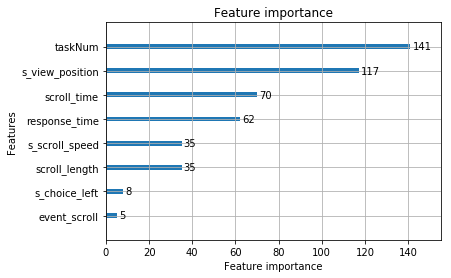

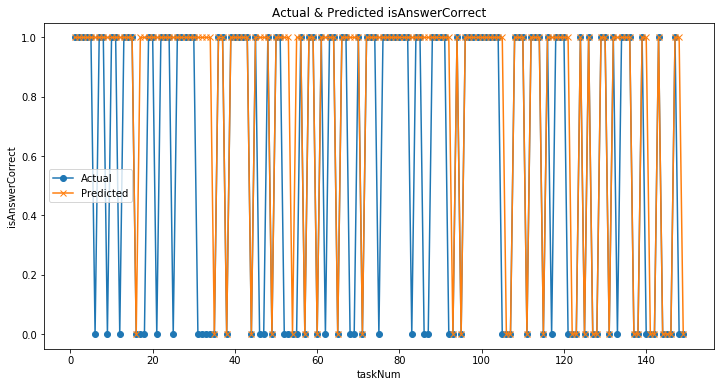

True Positives: 89
True Negatives: 30
False Positives: 30
False Negatives: 0


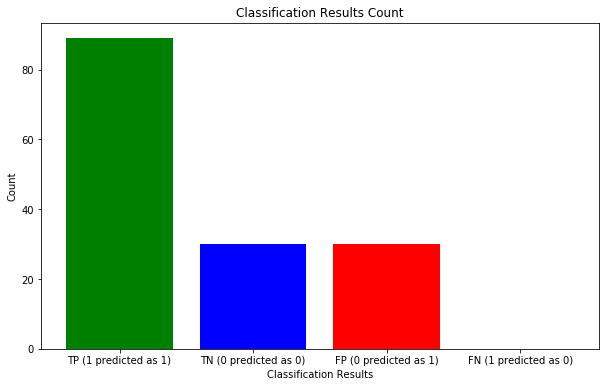

In [13]:
# カレントディレクトリを表示
current_directory = os.getcwd()
print(f'Current Directory: {current_directory}')

actual = df[target].iloc[1:].astype(int)
predicted = df['predicted_isAnswerCorrect'].iloc[1:].astype(int)

accuracy = accuracy_score(actual, predicted)
print(f'Overwell accuracy: {accuracy}')

print(model.params)

# 特徴量の重要度出力
print(model.feature_importance())

# 特徴量の重要度をプロット
lgb.plot_importance(model)

# 図示
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(actual) + 1), actual, label='Actual', marker='o')
plt.plot(range(1, len(predicted) + 1), predicted, label='Predicted', marker='x')
plt.xlabel('taskNum')
plt.ylabel('isAnswerCorrect')
plt.title('Actual & Predicted isAnswerCorrect')
plt.legend()
plt.show()

# 分類結果のカウント
tp = np.sum((actual == 1) & (predicted == 1))
tn = np.sum((actual == 0) & (predicted == 0))
fp = np.sum((actual == 0) & (predicted == 1))
fn = np.sum((actual == 1) & (predicted == 0))

print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')

# グラフの描画
labels = ['TP (1 predicted as 1)', 'TN (0 predicted as 0)', 'FP (0 predicted as 1)', 'FN (1 predicted as 0)']
counts = [tp, tn, fp, fn]

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['green', 'blue', 'red', 'orange'])
plt.xlabel('Classification Results')
plt.ylabel('Count')
plt.title('Classification Results Count')
plt.show()

# 前回

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# モデルの訓練
model = LogisticRegression()
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 結果の表示
print(f　'Predicted isAnswerCorrect for taskNum == {n}: {y_pred}')


SyntaxError: invalid character in identifier (<ipython-input-11-ae00ea365d00>, line 12)

In [ ]:
# taskNumが1のデータ
train_data = df[df['taskNum'] == 1]
X_train = df.drop(columns=['isAnswerCorrect'])
y_train = df['isAnswerCorrect']

# taskNumが2のデータ
test_data = df[df['taskNum'] == 2]
X_test = test_data.drop(columns=['isAnswerCorrect'])
y_test = test_data['isAnswerCorrect']

# # 全てのカラムをfloatに変換
# data_clean = data_clean.astype(float)

# LightGBM用データセットの作成
train_dataset = lgb.Dataset(X_train, label=y_train)
test_dataset = lgb.Dataset(X_test, label=y_test, reference=train_dataset)

# モデルの設定
params = {
    'objective': 'binary',
    'metric':'auc',
}

# モデルの作成と訓練
model = lgb.train(params,train_dataset,num_boost_round=1000,valid_sets=test_dataset )

# 保存
model.save_model('model.txt')

# 予測
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# AUC (Area Under the Curve) を計算する
fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred)
auc = metrics.auc(fpr, tpr)
print(auc)

# ROC曲線をプロット
plt.plot(fpr, tpr, label='ROC curve (area = %.2f)'%auc)
plt.legend()
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)

# 特徴量の重要度出力
print(model.feature_importance())

# 特徴量の重要度をプロット
lgb.plot_importance(model)

In [ ]:
print(dataset['isAnswerCorrect'].value_counts())
Y = dataset['isAnswerCorrect']
Y = dataset['isAnswerCorrect'].replace({True: 1, False: 0})
print(Y.value_counts())

X = dataset.drop(columns=['isAnswerCorrect','sensor_id','data_time','event','Unnamed: 0'],axis = 1)
print(X.columns)

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=0,shuffle=True)
lgb_train=lgb.Dataset(X_train,Y_train)
lgb_eval=lgb.Dataset(X_test,Y_test,reference=lgb_train)

In [ ]:
from lightgbm import LGBMRegressor
params = {
    'objective': 'binary',
    'metrics':'binary_logloss',
#     'boosting_type':'gbdt',
#     'verbosity': -1,
#     'random_state': 42,
#     'learning_rate': 0.01,
#     'verbose_eval':50,
#     'early_stopping_rounds':100
}
print("タイプ：",type(lgb_train))
model = lgb.train(params,lgb_train,num_boost_round=1000,valid_sets=lgb_eval)
model.save_model('model.txt')
print(model.params)

In [ ]:
# AUC (Area Under the Curve) を計算する
Y_pred = model.predict(X_test, num_iteration=model.best_iteration)
fpr, tpr, thresholds = metrics.roc_curve(Y_test,Y_pred)
auc = metrics.auc(fpr, tpr)
print(auc)

# ROC曲線をプロット
plt.plot(fpr, tpr, label='ROC curve (area = %.2f)'%auc)
plt.legend()
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)

# 特徴量の重要度出力
print(model.feature_importance())

# 特徴量の重要度をプロット
lgb.plot_importance(model)